<h1 id="step-1" style="color:#FF1493;"> Analysis of Sentiment-Associated Words in Persian SnappFood Reviews </h1>

<h2 style="color:#00BFC4;"> Data Analysis Final Project - Ala A. </h2>

### Project objective

The purpose of this project is to analyse Persian customer comments from
SnappFood and identify the words and phrases most strongly associated with
positive (`HAPPY`) and negative (`SAD`) reviews.

<h3>Project Structure</h3>

<ol>
    <li>
        <a href="#step-1">
            Step 1: Project Overview
        </a>
    </li>

<li>
        <a href="#step-2">
            Step 2: Loading and Inspecting the Dataset
        </a>
    </li>

<li>
        <a href="#step-3">
            Step 3: Initial Data Quality Assessment
        </a>
    </li>

<li>
        <a href="#step-4">
            Step 4: Cleaning the Dataset
        </a>
    </li>

<li>
        <a href="#step-5">
            Step 5: Persian Text Preprocessing
        </a>
    </li>

 <li>
        <a href="#step-6">
            Step 6: Exploratory Text Analysis
        </a>
    </li>

<li>
        <a href="#step-7">
            Step 7: Word Frequency Analysis
        </a>
    </li>

 <li>
        <a href="#step-8">
            Step 8: Sentiment Association Analysis
        </a>
    </li>

 <li>
        <a href="#step-9">
            Step 9: Context and Phrase Analysis
        </a>
    </li>

 <li>
        <a href="#step-10">
            Step 10: Summary of the Main Results
        </a>
    </li>

  <li>
        <a href="#step-11">
            Step 11: Limitations and Conclusion
        </a>
    </li>
</ol>

<h1 id="step-2" style="color:#FF1493;">Step 2: Loading and Inspecting the Dataset</h1>

<h2 style="color:#00BFC4;">Importing the Required Libraries</h2>

<p>
In this section, the required Python libraries are imported, the SnappFood
dataset is loaded, and its basic structure is examined.
</p>

In [63]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# display more text from long Persian comments
pd.set_option("display.max_colwidth", 200)

# display all dataset columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


<h2 style="color:#00BFC4;">Loading the SnappFood Dataset</h2>

<p>
The dataset file uses tab characters as column separators rather than
ordinary commas. Therefore, the <code>sep="\t"</code> was used
when reading the file with pandas.
</p>

In [64]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path.cwd() / "data" / "snappfood_comments.csv"

try:
    df = pd.read_csv(
        DATA_PATH,
        sep="\t",
        encoding="utf-8-sig",
        low_memory=False
    )

    print("Dataset loaded successfully.")

except FileNotFoundError:
    print(f"File not found: {DATA_PATH}")

Dataset loaded successfully.


In [65]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

Rows: 70,000
Columns: 4

Column names:
['Unnamed: 0', 'comment', 'label', 'label_id']


In [4]:
df.head()

,Unnamed: 0,comment,label,label_id
0,NaN,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1.0
1,NaN,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون,HAPPY,0.0
2,NaN,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1.0
3,NaN,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,0.0
4,NaN,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0.0


In [66]:
df.shape

(70000, 4)

In [67]:
df.columns.tolist()

['Unnamed: 0', 'comment', 'label', 'label_id']

<h1 id="step-3" style="color:#FF1493;">Step 3: Initial Data Quality Assessment</h1>

<h2 style="color:#00BFC4;">Removing Unnecessary Columns</h2>

<p>
Before analysing the comments, the dataset structure is cleaned and checked
for missing values, duplicate records, invalid labels, and class imbalance.
</p>

In [68]:
# remove the automatically saved index column
df = df.drop(columns=["Unnamed: 0"])

print("Updated dataset shape:", df.shape)
print("Remaining columns:", df.columns.tolist())

Updated dataset shape: (70000, 3)
Remaining columns: ['comment', 'label', 'label_id']


In [69]:
df.head()

,comment,label,label_id
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1.0
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون,HAPPY,0.0
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1.0
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,0.0
4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0.0


<h2 style="color:#00BFC4;">Dataset Information</h2>

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   comment   70000 non-null  str    
 1   label     70000 non-null  str    
 2   label_id  69480 non-null  float64
dtypes: float64(1), str(2)
memory usage: 12.5 MB


<h2 style="color:#00BFC4;">Missing Value Analysis</h2>

<p>
Missing values are checked because comments without text or labels cannot
be used reliably in sentiment analysis.
</p>

In [71]:
missing_values = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

missing_values

,Missing Count,Missing Percentage
comment,0,0.00
label,0,0.00
label_id,520,0.74


In [72]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 520


In [12]:
empty_comments = (
    df["comment"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Number of empty comments:", empty_comments)

Number of empty comments: 0


<h2 style="color:#00BFC4;">Sentiment Label Inspection</h2>

In [73]:
print("Unique text labels:")
print(df["label"].unique())

print("\nUnique numerical labels:")
print(df["label_id"].unique())

Unique text labels:
<ArrowStringArray>
['SAD', 'HAPPY', '1', '0']
Length: 4, dtype: str

Unique numerical labels:
[ 1.  0. nan]


In [74]:
label_mapping = (
    df[["label", "label_id"]]
    .drop_duplicates()
    .sort_values("label_id")
)

label_mapping

,label,label_id
1,HAPPY,0.0
0,SAD,1.0
21,1,NaN
243,0,NaN


In [75]:
label_counts = df["label"].value_counts()

label_counts

label
HAPPY    34916
SAD      34564
1          436
0           84
Name: count, dtype: int64

In [76]:
label_distribution = pd.DataFrame({
    "Count": df["label"].value_counts(),
    "Percentage": (
        df["label"].value_counts(normalize=True) * 100
    ).round(2)
})

label_distribution

,Count,Percentage
label,,
HAPPY,34916,49.88
SAD,34564,49.38
1,436,0.62
0,84,0.12


<h2 style="color:#00BFC4;">Sentiment Distribution Visualization</h2>

<p>
The following bar chart compares the number of positive and negative comments
in the dataset.
</p>

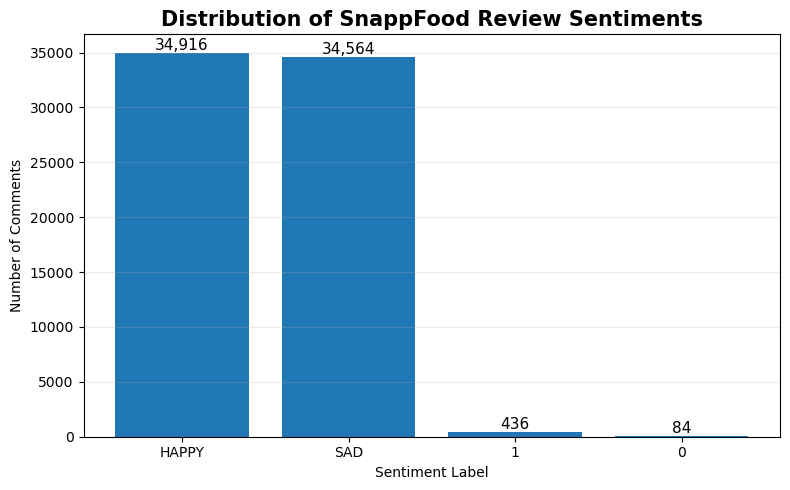

In [77]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    label_counts.index,
    label_counts.values
)

plt.title(
    "Distribution of SnappFood Review Sentiments",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Sentiment Label")
plt.ylabel("Number of Comments")

plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 300,
        f"{int(height):,}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

<h2 style="color:#00BFC4;">Duplicate Record Analysis</h2>

<p>
Duplicate comments may influence word frequencies by causing some expressions
to be counted more often than they should be. They are inspected before any
records are removed.
</p>

In [78]:
complete_duplicate_count = df.duplicated().sum()

print("Number of completely duplicated rows:", complete_duplicate_count)

Number of completely duplicated rows: 518


In [80]:
duplicate_comment_count = df.duplicated(
    subset=["comment"],
    keep=False
).sum()

print(
    "Number of rows containing duplicated comment text:",
    duplicate_comment_count
)

Number of rows containing duplicated comment text: 520


In [82]:
duplicate_comments = (
    df[df.duplicated(subset=["comment"], keep=False)]
    .sort_values("comment")
)

duplicate_comments.head(20)

,comment,label,label_id
243,HAPPY,0,NaN
415,HAPPY,0,NaN
2173,HAPPY,0,NaN
3905,HAPPY,0,NaN
5114,HAPPY,0,NaN
5458,HAPPY,0,NaN
5523,HAPPY,0,NaN
6535,HAPPY,0,NaN
7674,HAPPY,0,NaN
9418,HAPPY,0,NaN


In [84]:
label_count_per_comment = (
    df.groupby("comment")["label"]
    .nunique()
)

conflicting_comments = label_count_per_comment[
    label_count_per_comment > 1
]

print(
    "Number of identical comments with conflicting labels:",
    len(conflicting_comments)
)

Number of identical comments with conflicting labels: 0


In [85]:
if len(conflicting_comments) > 0:
    conflicting_examples = df[
        df["comment"].isin(conflicting_comments.index)
    ].sort_values("comment")

    display(conflicting_examples.head(20))
else:
    print("No conflicting labels were found.")

No conflicting labels were found.


In [86]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Total missing values",
        "Empty comments",
        "Completely duplicated rows",
        "Rows with duplicated comment text",
        "Comments with conflicting labels"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isna().sum().sum(),
        empty_comments,
        complete_duplicate_count,
        duplicate_comment_count,
        len(conflicting_comments)
    ]
})

quality_summary

,Metric,Value
0,Number of rows,70000
1,Number of columns,3
2,Total missing values,520
3,Empty comments,0
4,Completely duplicated rows,518
5,Rows with duplicated comment text,520
6,Comments with conflicting labels,0


In [87]:
df.isna().sum()

comment       0
label         0
label_id    520
dtype: int64

In [88]:
label_mapping

,label,label_id
1,HAPPY,0.0
0,SAD,1.0
21,1,NaN
243,0,NaN


In [89]:
label_distribution

,Count,Percentage
label,,
HAPPY,34916,49.88
SAD,34564,49.38
1,436,0.62
0,84,0.12


In [90]:
quality_summary

,Metric,Value
0,Number of rows,70000
1,Number of columns,3
2,Total missing values,520
3,Empty comments,0
4,Completely duplicated rows,518
5,Rows with duplicated comment text,520
6,Comments with conflicting labels,0


<h1 style="color:#FF1493;">Step 4: Cleaning the Dataset</h1>

<h2 style="color:#00BFC4;">Removing Invalid and Duplicate Records</h2>

<p>
Rows with invalid sentiment labels or missing numerical labels are removed.
Repeated comment texts are also removed to prevent duplicate reviews from
distorting the word-frequency analysis.
</p>

In [91]:
original_size = len(df)

df = (
    df[df["label"].isin(["HAPPY", "SAD"])]
    .dropna(subset=["comment", "label_id"])
    .drop_duplicates(subset=["comment"])
    .reset_index(drop=True)
)

df["label_id"] = df["label_id"].astype(int)

print(f"Original rows: {original_size:,}")
print(f"Clean rows: {len(df):,}")
print(f"Removed rows: {original_size - len(df):,}")

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate comments:", df["comment"].duplicated().sum())

print("\nSentiment distribution:")
print(df["label"].value_counts())

Original rows: 70,000
Clean rows: 69,480
Removed rows: 520

Missing values:
comment     0
label       0
label_id    0
dtype: int64

Duplicate comments: 0

Sentiment distribution:
label
HAPPY    34916
SAD      34564
Name: count, dtype: int64


In [92]:
df.groupby("label")["label_id"].unique()

label
HAPPY    [0]
SAD      [1]
Name: label_id, dtype: object

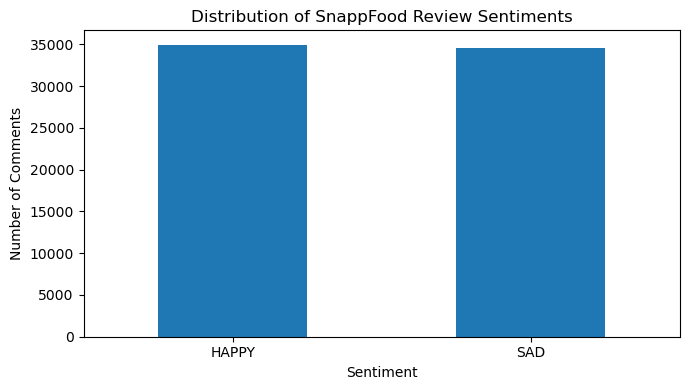

In [93]:
sentiment_counts = df["label"].value_counts()

sentiment_counts.plot(
    kind="bar",
    figsize=(7, 4),
    title="Distribution of SnappFood Review Sentiments"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<h1 style="color:#FF1493;">Step 5: Persian Text Preprocessing</h1>

<h2 style="color:#00BFC4;">Normalizing and Tokenizing the Comments</h2>

<p>
Persian comments may contain different forms of the same character,
punctuation, links, numbers, emojis, and informal spellings. The comments
are normalized before their sentiment-related words are counted.
</p>

In [94]:
import re
import unicodedata

# common words 
stopwords = {
    "و", "در", "به", "از", "که", "این", "آن", "را", "با", "برای",
    "تا", "یا", "اما", "ولی", "اگر", "چون", "چه", "هر", "هم",
    "همه", "یک", "دو", "روی", "تو", "من", "ما", "شما", "او",
    "آنها", "اینا", "اونا", "اون", "یه", "رو", "برا", "واسه",
    "است", "هست", "هستم", "هستند", "بود", "بوده", "شد", "شده",
    "می", "شود", "کرد", "کرده", "کنه", "کنند", "داشت", "دارد",
    "دارم", "دارند", "خود", "دیگه", "دیگر", "فقط", "مثل"
}

def normalize_persian(text):
    text = unicodedata.normalize("NFKC", str(text))

    # normalize common Arabic characters
    text = text.translate(str.maketrans({
        "ي": "ی",
        "ى": "ی",
        "ك": "ک",
        "ۀ": "ه",
        "ة": "ه",
        "\u200c": " "   # Replace half-space with normal space
    }))

    # remove links and Latin text
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[A-Za-z]+", " ", text)

    # remove numbers
    text = re.sub(r"[0-9۰-۹٠-٩]+", " ", text)

    # remove punctuation, emojis and other symbols
    text = "".join(
        character if character.isalpha() or character.isspace() else " "
        for character in text
    )

    # reduce exaggerated letters: عاااالی → عالی
    text = re.sub(r"([آ-ی])\1{2,}", r"\1", text)

    # remove extra spaces
    return re.sub(r"\s+", " ", text).strip()

In [95]:
# normalize each original comment
df["normalized_comment"] = df["comment"].apply(normalize_persian)

# split comments into words and remove stopwords
df["tokens"] = df["normalized_comment"].apply(
    lambda text: [
        word for word in text.split()
        if word not in stopwords and len(word) > 1
    ]
)

# join the useful words
df["clean_comment"] = df["tokens"].str.join(" ")

print("Preprocessing completed.")
print("Comments with no remaining keywords:",
      df["clean_comment"].eq("").sum())

Preprocessing completed.
Comments with no remaining keywords: 248


In [96]:
comparison = df[
    ["comment", "normalized_comment", "clean_comment"]
].sample(10, random_state=42)

comparison

,comment,normalized_comment,clean_comment
51167,غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است,غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است,غذا خیلی سرد صورتیکه فاصله خیلی کم
22846,بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم,بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم,بهتره بتونیم ران سینه خودمون انتخاب کنیم
30915,غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه. معلوم نیست چی توش ریختن. افتضاااااااااح بود. دوساعته ک حالم بده.,غذا بد بود حالم خیلی بده دل دردو دل پیچه معلوم نیست چی توش ریختن افتضاح بود دوساعته ک حالم بده,غذا بد حالم خیلی بده دل دردو دل پیچه معلوم نیست چی توش ریختن افتضاح دوساعته حالم بده
8011,با سلام سابق بر این بسته بندی از کیفیت بهتری برخوردار بود. ولی در حال حاضر ایراداتی وجود داره. به طور نمونه نوشابه قوطی فاقد نی هست، چنگال برای سرو سیب زمینی نداره، دستمال کاغذی هم در بسته بندی نیست.,با سلام سابق بر این بسته بندی از کیفیت بهتری برخوردار بود ولی در حال حاضر ایراداتی وجود داره به طور نمونه نوشابه قوطی فاقد نی هست چنگال برای سرو سیب زمینی نداره دستمال کاغذی هم در بسته بندی نیست,سلام سابق بر بسته بندی کیفیت بهتری برخوردار حال حاضر ایراداتی وجود داره طور نمونه نوشابه قوطی فاقد نی چنگال سرو سیب زمینی نداره دستمال کاغذی بسته بندی نیست
28563,سلام، خیلی ممنون و متشکرم,سلام خیلی ممنون و متشکرم,سلام خیلی ممنون متشکرم
11541,خیلی زود رسید و ممنون م ازشون,خیلی زود رسید و ممنون م ازشون,خیلی زود رسید ممنون ازشون
55679,مواد پیتزا بسیااار کم بود با اینکه قیمت اصلا پایین نیست. ولی کلا طعم پیتزا خوب و تازه بود,مواد پیتزا بسیار کم بود با اینکه قیمت اصلا پایین نیست ولی کلا طعم پیتزا خوب و تازه بود,مواد پیتزا بسیار کم اینکه قیمت اصلا پایین نیست کلا طعم پیتزا خوب تازه
53501,کیفیت زیاد خوب نبود،,کیفیت زیاد خوب نبود,کیفیت زیاد خوب نبود
13279,مرغی که واسه ما آوردن بو میداد انگار که مونده بود!,مرغی که واسه ما آوردن بو میداد انگار که مونده بود,مرغی آوردن بو میداد انگار مونده
28825,همه چی خوب بود. ولی اگه تخفیف نداشتم اصلا خرید نمی‌کردم چون گرونه برام:),همه چی خوب بود ولی اگه تخفیف نداشتم اصلا خرید نمی کردم چون گرونه برام,چی خوب اگه تخفیف نداشتم اصلا خرید نمی کردم گرونه برام


In [99]:
OUTPUT_PATH = Path.cwd() / "outputs" / "snappfood_cleaned.csv"

df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Processed dataset saved")

Processed dataset saved


<h1 style="color:#FF1493;">Step 6: Exploratory Text Analysis</h1>

<h2 style="color:#00BFC4;">Comment Length by Sentiment</h2>

<p>
Comment length is analysed to determine whether positive and negative
customers differ in how much they write.
</p>

In [100]:
# keep the original dataset, but exclude comments with no useful tokens
analysis_df = df[df["tokens"].str.len() > 0].copy()

analysis_df["character_count"] = (
    analysis_df["normalized_comment"].str.len()
)

analysis_df["word_count"] = (
    analysis_df["normalized_comment"].str.split().str.len()
)

analysis_df["keyword_count"] = (
    analysis_df["tokens"].str.len()
)

print(f"Comments available for word analysis: {len(analysis_df):,}")

Comments available for word analysis: 69,232


In [101]:
length_summary = (
    analysis_df.groupby("label")[
        ["character_count", "word_count", "keyword_count"]
    ]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

length_summary

character_count                  word_count                  \
                 mean median min   max       mean median min  max   
label                                                               
HAPPY           75.43   56.0   4   902      16.21   12.0   1  201   
SAD            100.16   77.0  10  1650      21.41   16.0   3  352   

      keyword_count                  
               mean median min  max  
label                                
HAPPY         11.42    8.0   1  136  
SAD           15.30   12.0   1  259

In [102]:
simple_length_summary = (
    analysis_df.groupby("label")
    .agg(
        comments=("comment", "count"),
        average_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        average_keywords=("keyword_count", "mean")
    )
    .round(2)
)

simple_length_summary

,comments,average_words,median_words,average_keywords
label,,,,
HAPPY,34770,16.21,12.0,11.42
SAD,34462,21.41,16.0,15.30


<h2 style="color:#00BFC4;">Average Number of Words</h2>

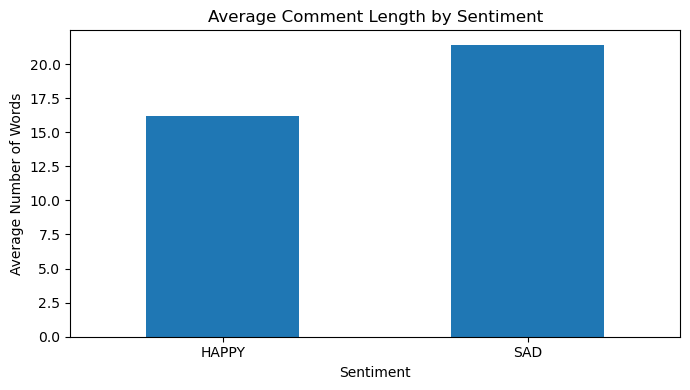

In [104]:
average_words = analysis_df.groupby("label")["word_count"].mean()

average_words.plot(
    kind="bar",
    figsize=(7, 4),
    title="Average Comment Length by Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

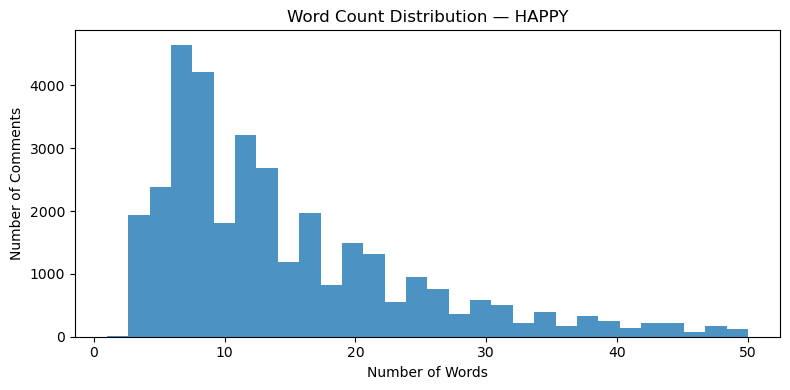

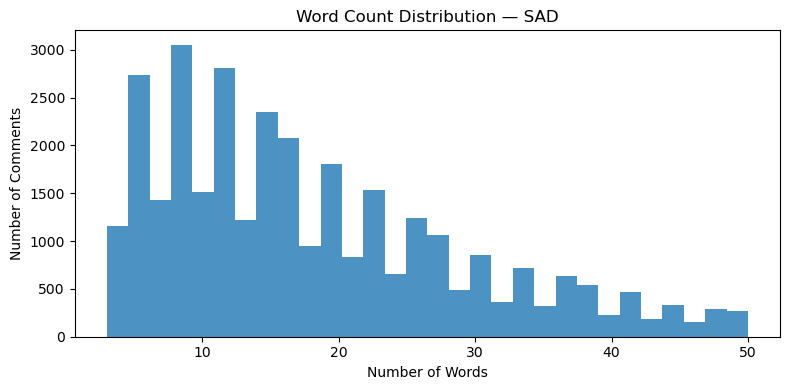

In [105]:
for label in ["HAPPY", "SAD"]:
    values = analysis_df.loc[
        (analysis_df["label"] == label) &
        (analysis_df["word_count"] <= 50),
        "word_count"
    ]

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=30, alpha=0.8)

    plt.title(f"Word Count Distribution — {label}")
    plt.xlabel("Number of Words")
    plt.ylabel("Number of Comments")
    plt.tight_layout()
    plt.show()

In [106]:
analysis_df.to_csv(
    Path.cwd() / "outputs" / "snappfood_analysis_ready.csv",
    index=False,
    encoding="utf-8-sig"
)

<h2 style="color:#00BFC4;">Comment-Length Finding</h2>

<p>
Negative reviews were generally longer than positive reviews. SAD comments
contained an average of 21.41 words, while HAPPY comments contained 16.21
words. This suggests that dissatisfied customers tend to provide more detail
when explaining problems with their orders.
</p>

<h1 style="color:#FF1493;">Step 7: Word Frequency Analysis</h1>

<h2 style="color:#00BFC4;">Most Frequent Words by Sentiment</h2>

<p>
Useful words are counted separately in positive and negative reviews after
normalization and stopword removal.
</p>

In [134]:
from collections import Counter

happy_words = Counter(
    word
    for tokens in analysis_df.loc[
        analysis_df["label"] == "HAPPY", "tokens"
    ]
    for word in tokens
)

sad_words = Counter(
    word
    for tokens in analysis_df.loc[
        analysis_df["label"] == "SAD", "tokens"
    ]
    for word in tokens
)

happy_top20 = pd.DataFrame(
    happy_words.most_common(20),
    columns=["word", "frequency"]
)

sad_top20 = pd.DataFrame(
    sad_words.most_common(20),
    columns=["word", "frequency"]
)

print("Most frequent HAPPY words:")
display(happy_top20)

print("Most frequent SAD words:")
display(sad_top20)

Most frequent HAPPY words:


,word,frequency
0,عالی,12627
1,خیلی,11329
2,خوب,10101
3,غذا,6436
4,کیفیت,6250
5,خوشمزه,5466
6,ممنون,4679
7,رسید,4630
8,بسیار,3910
9,سفارش,3669


Most frequent SAD words:


,word,frequency
0,غذا,9169
1,خیلی,9092
2,کیفیت,8166
3,سفارش,7856
4,نبود,6224
5,اصلا,5763
6,سرد,5116
7,پیتزا,5021
8,بسیار,4705
9,بد,4295


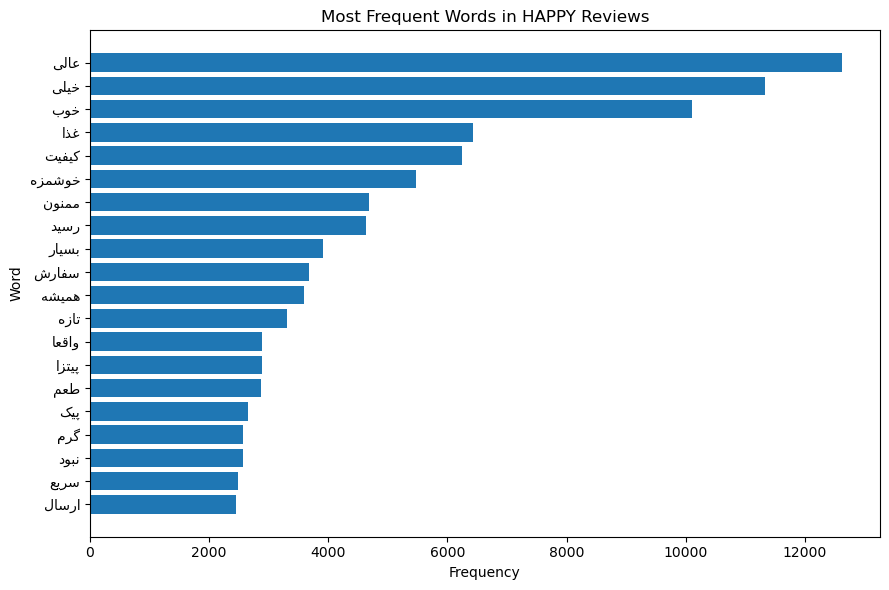

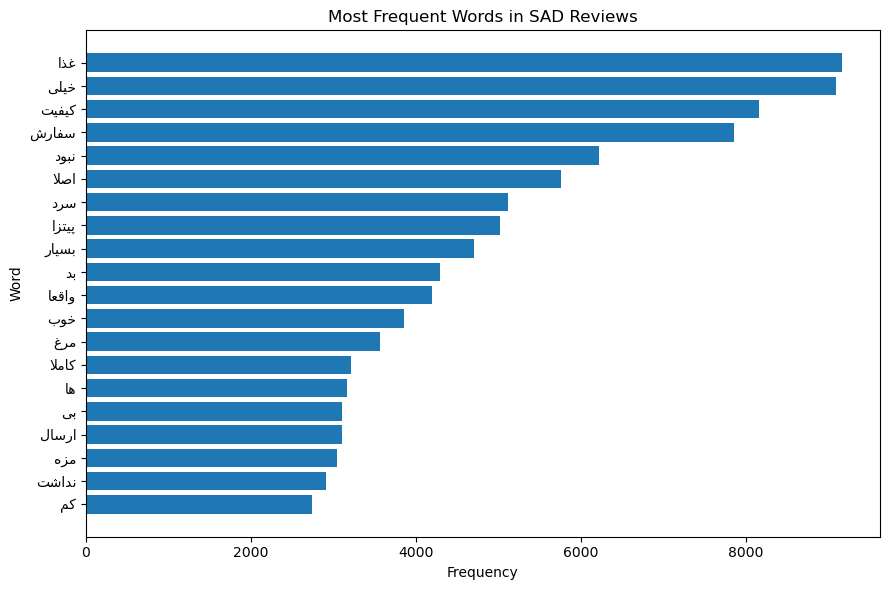

In [109]:
import arabic_reshaper
from bidi.algorithm import get_display

def persian_display(text):
    return get_display(arabic_reshaper.reshape(str(text)))

def plot_top_words(data, title):
    plot_data = data.sort_values("frequency")

    plt.figure(figsize=(9, 6))
    plt.barh(
        [persian_display(word) for word in plot_data["word"]],
        plot_data["frequency"]
    )

    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

plot_top_words(
    happy_top20,
    "Most Frequent Words in HAPPY Reviews"
)

plot_top_words(
    sad_top20,
    "Most Frequent Words in SAD Reviews"
)

In [110]:
happy_top20.to_csv(
    Path.cwd() / "outputs" / "top_happy_words.csv",
    index=False,
    encoding="utf-8-sig"
)

sad_top20.to_csv(
    Path.cwd() / "outputs" / "top_sad_words.csv",
    index=False,
    encoding="utf-8-sig"
)

<h1 style="color:#FF1493;">Step 8: Sentiment Association Analysis</h1>

<h2 style="color:#00BFC4;">Identifying Words Strongly Associated with HAPPY and SAD Reviews</h2>

<p>
Raw frequency does not always indicate sentiment. Some words appear frequently
in both classes. A log-odds ratio is therefore calculated to identify words
that occur proportionally more often in one sentiment than the other.
</p>

In [111]:
all_words = set(happy_words) | set(sad_words)

association = pd.DataFrame({
    "word": list(all_words),
    "happy_count": [happy_words[word] for word in all_words],
    "sad_count": [sad_words[word] for word in all_words]
})

total_happy = sum(happy_words.values())
total_sad = sum(sad_words.values())

association["score"] = np.log(
    ((association["happy_count"] + 0.5) /
     (total_happy - association["happy_count"] + 0.5))
    /
    ((association["sad_count"] + 0.5) /
     (total_sad - association["sad_count"] + 0.5))
)

association["total_count"] = (
    association["happy_count"] + association["sad_count"]
)

association = association[
    (association["total_count"] >= 50)
    & (association["word"].str.len() > 1)
].copy()

In [112]:
happy_associated = (
    association
    .sort_values("score", ascending=False)
    .head(20)
    [["word", "happy_count", "sad_count", "score"]]
)

sad_associated = (
    association
    .sort_values("score")
    .head(20)
    [["word", "happy_count", "sad_count", "score"]]
)

print("Words most associated with HAPPY reviews:")
display(happy_associated)

print("Words most associated with SAD reviews:")
display(sad_associated)

Words most associated with HAPPY reviews:


,word,happy_count,sad_count,score
10557,چسبید,77,0,5.327380
2589,دمتون,237,3,4.501757
23166,نظیره,53,1,3.858109
6065,نقص,79,3,3.406949
16959,ممنونم,1675,77,3.361432
3508,وخوشمزه,51,2,3.309177
21029,لذیذ,358,17,3.304359
3124,عالی,12627,704,3.200890
13935,منظم,75,4,3.103998
14595,بردم,125,7,3.101466


Words most associated with SAD reviews:


,word,happy_count,sad_count,score
15184,پشیمونم,1,62,-3.446055
13769,بدترین,13,514,-3.357687
21854,متاسفم,29,947,-3.187400
9607,آخرین,9,270,-3.065709
22292,آبروم,2,69,-3.041401
8789,افتضاح,59,1399,-2.876641
18740,انداختم,5,110,-2.716702
4997,حالم,3,65,-2.645642
2914,تاسف,8,155,-2.623092
12157,صفر,4,75,-2.536426


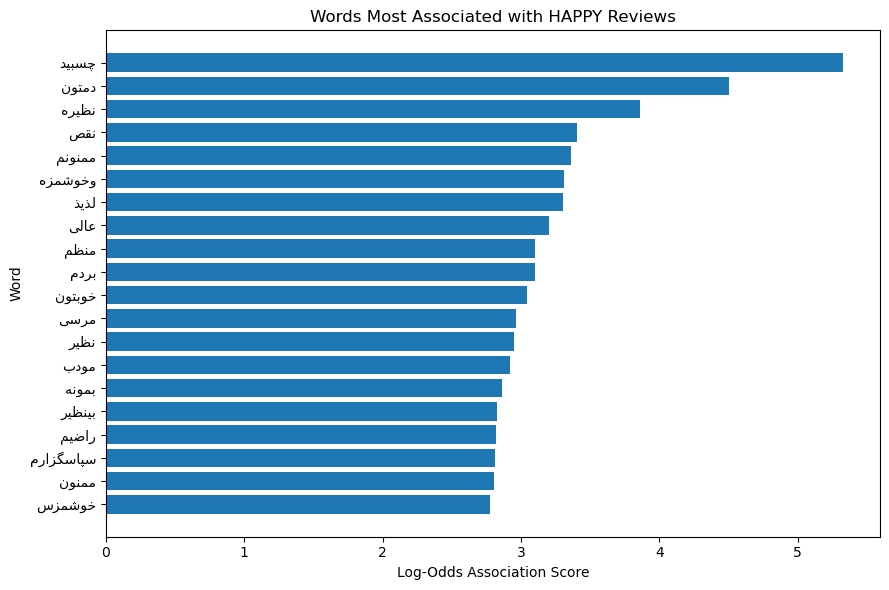

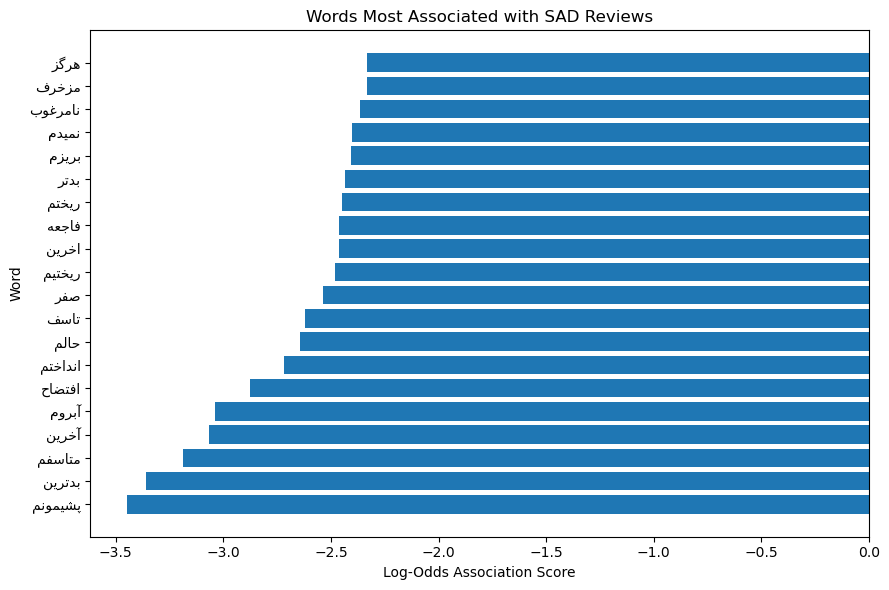

In [113]:
def plot_association(data, title):
    plot_data = data.sort_values("score")

    plt.figure(figsize=(9, 6))
    plt.barh(
        [persian_display(word) for word in plot_data["word"]],
        plot_data["score"]
    )

    plt.title(title)
    plt.xlabel("Log-Odds Association Score")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()


plot_association(
    happy_associated,
    "Words Most Associated with HAPPY Reviews"
)

plot_association(
    sad_associated,
    "Words Most Associated with SAD Reviews"
)

In [114]:
happy_associated.to_csv(
    Path.cwd() / "outputs" / "happy_associated_words.csv",
    index=False,
    encoding="utf-8-sig"
)

sad_associated.to_csv(
    Path.cwd() / "outputs" / "sad_associated_words.csv",
    index=False,
    encoding="utf-8-sig"
)

<h1 style="color:#FF1493;">Step 9: Context and Phrase Analysis</h1>

<h2 style="color:#00BFC4;">Inspecting Words in Their Original Context</h2>

<p>
Individual words may have different meanings depending on the words around
them. Therefore, unexpected results are checked inside their original comments.
</p>

In [115]:
def show_word_examples(word, n=10):
    examples = df[
        df["normalized_comment"].str.contains(
            word, regex=False, na=False
        )
    ][["comment", "label"]]

    return examples.sample(
        min(n, len(examples)),
        random_state=42
    )

show_word_examples("نقص", 15)

,comment,label
31392,بی نظیر. پنج ستاره. بی نقص,HAPPY
15449,عاااااالی سریع و بدون نقص,HAPPY
41709,بسیار سریع و کامل و بدپن نقص به دستم رسید، ممنون,HAPPY
51028,با اختلاف بهترین غذا در بین رستوران‌ها و کتریتگ‌های منطقه کیفیت و حجم غذا بسیار خوب، دورچین و بسته بندی بی نقص,HAPPY
1429,سلام همیشه سوپر مارکت هاتون نقص دارن و‌هیچ وقت کامل سفارشو نمیارن,HAPPY
19827,عالی عالی!! ممنون که به توضیحات سفارش دقت می‌کنید کیفیت، حجم و ارسال همگی بی نقص,HAPPY
30523,مثل همیشه عالی بود. از خریدم کاملا راضی بودم. فقط اگر امکانش باشه گرم به دستمون برسه و شکلاتشم یه کم بیشتر کنید بی نقص میشه!,HAPPY
48671,به موقع و بی نقص اوردن,HAPPY
9622,سریع و دقیق و بدون نقص، ممنونم.,HAPPY
33216,تازه و عالی و بی نقص … موزها بی لک و مجلسی بودند. ممنونم و پایدار باشید.,HAPPY


In [117]:
show_word_examples("آخرین", 10)

,comment,label
904,"با اینکه توی سفارش تاکید کرده بودم شیرینی‌ها تازه باشه, شیرینی ها, مخصوصا دانمارکی, به شدت کهنه و مونده بود. آخرین باری بود که از اینجا چیزی سفارش دادم. ۳۲هزار تومن پول رو ریختم بیرون انگار! وجدان...",SAD
58412,مطمئنا اولین و آخرین بار بود,SAD
38248,کیفیت پاستا و پیتزا ضیعف بود ولی حجم آنها مناسب بود در کل آخرین خرید من از این مجموعه خواهد بود!,SAD
49839,اولین و آخرین بارمه از اینجا سفارش میدم. همین با تشکر,SAD
17064,اصلا خوب نبود آخرین خریدم بود از این شیرینی فروشی,SAD
55468,من همیشه از این رستوران سفارش میدادم ولى متاسفانه کیفیت غذاها افت کرده واین آخرین سفارشم بود,SAD
60645,یک ساعت و نیم انتظار برای یه ساندویچ ۱۵ سانتی. هر روز حجم کمتر، قیمت بالاتر و تاخیر بیشتر. آخرین سفارشم بود,SAD
42510,افتضاح بود غذا کاملا سرد رسید اولین و آخرین سفارشم از این رستوران خواهد بود,SAD
8601,اصلا اصلا کیفیت پیتزا خوب نبود پیتزا سبزیجات بیشتر نخود داشتغذا سرد بود … قارچ سوخاری فوق العاده بی مزه بوددددد ….. آخرین باری بود که از شما غذا میگیرررم اصلا راضی نبوددددم,SAD
54199,واقعا افتضاح بود. آخرین باری بود که از این رستوران سفارش می‌دهم. گوشت برگر خام بود، پنیری وجود نداشت، از سس باربیکیو هم خبری نبود. علاوه بر تمام این‌ها غذا بسیار سرد بود.,SAD


<h2 style="color:#00BFC4;">Bigrams Associated with Each Sentiment</h2>

<p>
Two-word phrases are compared using a log-odds score. Positive scores indicate
association with HAPPY reviews, while negative scores indicate association
with SAD reviews.
</p>

<h1 style="color:#FF1493;">Step 9: Improved Phrase Analysis</h1>

<h2 style="color:#00BFC4;">Extracting True Adjacent Bigrams</h2>

<p>
Bigrams are extracted from the normalized comments before stopword removal.
This prevents words that were not originally adjacent from being incorrectly
joined together.
</p>

In [119]:
def exact_bigrams(text):
    words = text.split()
    return [
        f"{first} {second}"
        for first, second in zip(words, words[1:])
    ]

analysis_df["exact_bigrams"] = (
    analysis_df["normalized_comment"].apply(exact_bigrams)
)

In [120]:
happy_bigram_docs = Counter()
sad_bigram_docs = Counter()

for phrases in analysis_df.loc[
    analysis_df["label"] == "HAPPY", "exact_bigrams"
]:
    happy_bigram_docs.update(set(phrases))

for phrases in analysis_df.loc[
    analysis_df["label"] == "SAD", "exact_bigrams"
]:
    sad_bigram_docs.update(set(phrases))

In [121]:
def meaningful_bigram(phrase):
    first, second = phrase.split()

    return (
        len(first) > 1
        and len(second) > 1
        and not (first in stopwords and second in stopwords)
    )

<h2 style="color:#00BFC4;">Statistically Reliable Phrase Association</h2>

<p>
A weighted log-odds z-score is used to identify phrases that differ reliably
between positive and negative comments. This method gives less importance to
rare phrases with insufficient evidence.
</p>

In [123]:
all_bigrams = set(happy_bigram_docs) | set(sad_bigram_docs)

bigram_results = pd.DataFrame({
    "bigram": list(all_bigrams)
})

bigram_results["happy_docs"] = bigram_results["bigram"].map(
    happy_bigram_docs
).fillna(0)

bigram_results["sad_docs"] = bigram_results["bigram"].map(
    sad_bigram_docs
).fillna(0)

happy_total = (analysis_df["label"] == "HAPPY").sum()
sad_total = (analysis_df["label"] == "SAD").sum()

a = bigram_results["happy_docs"] + 0.5
b = happy_total - bigram_results["happy_docs"] + 0.5
c = bigram_results["sad_docs"] + 0.5
d = sad_total - bigram_results["sad_docs"] + 0.5

bigram_results["log_odds"] = np.log((a / b) / (c / d))
bigram_results["standard_error"] = np.sqrt(
    1 / a + 1 / b + 1 / c + 1 / d
)

bigram_results["z_score"] = (
    bigram_results["log_odds"]
    / bigram_results["standard_error"]
)

bigram_results["total_docs"] = (
    bigram_results["happy_docs"]
    + bigram_results["sad_docs"]
)

bigram_results["happy_percentage"] = (
    bigram_results["happy_docs"]
    / bigram_results["total_docs"]
    * 100
).round(1)

bigram_results = bigram_results[
    (bigram_results["total_docs"] >= 100)
    & bigram_results["bigram"].apply(meaningful_bigram)
].copy()

In [124]:
happy_phrases = (
    bigram_results
    .sort_values("z_score", ascending=False)
    .head(20)
    [[
        "bigram",
        "happy_docs",
        "sad_docs",
        "happy_percentage",
        "z_score"
    ]]
)

sad_phrases = (
    bigram_results
    .sort_values("z_score")
    .head(20)
    [[
        "bigram",
        "happy_docs",
        "sad_docs",
        "happy_percentage",
        "z_score"
    ]]
)

print("Phrases associated with HAPPY reviews:")
display(happy_phrases)

print("Phrases associated with SAD reviews:")
display(sad_phrases)

Phrases associated with HAPPY reviews:


,bigram,happy_docs,sad_docs,happy_percentage,z_score
257992,عالی بود,5410,381,93.4,52.291024
136600,خوب بود,5867,1550,79.1,49.231359
24778,خوشمزه بود,2403,247,90.7,34.651821
252620,مثل همیشه,2170,292,88.1,32.681874
266854,خیلی خوب,1889,247,88.4,30.459449
46958,به موقع,1693,164,91.2,28.866179
275171,ممنون از,1334,94,93.4,25.066187
68799,بود ممنون,1107,46,96.0,21.299125
295436,همیشه عالی,986,55,94.7,20.960389
312627,بسیار عالی,991,43,95.8,20.278821


Phrases associated with SAD reviews:


,bigram,happy_docs,sad_docs,happy_percentage,z_score
163661,بد بود,158,1738,8.3,-29.414722
35084,بی کیفیت,87,1574,5.2,-26.731003
29848,سرد بود,596,1815,24.7,-24.229353
156876,خیلی بد,112,1030,9.8,-22.601400
135533,سفارش دادم,699,1782,28.2,-21.577384
248365,پایین بود,76,955,7.4,-21.498310
111005,خوب نبود,335,1132,22.8,-19.944940
281434,بعد از,231,966,19.3,-19.840781
222093,مونده بود,174,868,16.7,-19.616027
244582,کاملا سرد,136,807,14.4,-19.451775


<h1 style="color:#FF1493;">Step 10: Summary of the Main Results</h1>

<h2 style="color:#00BFC4;">Combining the Most Important Findings</h2>

<p>
The main findings from comment length, individual-word analysis, and
two-word phrase analysis are summarized in this section.
</p>

In [125]:
top_happy_words = (
    happy_associated
    .head(10)
    .assign(sentiment="HAPPY")
)

top_sad_words = (
    sad_associated
    .head(10)
    .assign(sentiment="SAD")
)

final_word_results = pd.concat(
    [top_happy_words, top_sad_words],
    ignore_index=True
)

final_word_results

,word,happy_count,sad_count,score,sentiment
0,چسبید,77,0,5.327380,HAPPY
1,دمتون,237,3,4.501757,HAPPY
2,نظیره,53,1,3.858109,HAPPY
3,نقص,79,3,3.406949,HAPPY
4,ممنونم,1675,77,3.361432,HAPPY
5,وخوشمزه,51,2,3.309177,HAPPY
6,لذیذ,358,17,3.304359,HAPPY
7,عالی,12627,704,3.200890,HAPPY
8,منظم,75,4,3.103998,HAPPY
9,بردم,125,7,3.101466,HAPPY


In [126]:
top_happy_phrases = (
    happy_phrases
    .head(10)
    .assign(sentiment="HAPPY")
)

top_sad_phrases = (
    sad_phrases
    .head(10)
    .assign(sentiment="SAD")
)

final_phrase_results = pd.concat(
    [top_happy_phrases, top_sad_phrases],
    ignore_index=True
)

final_phrase_results

,bigram,happy_docs,sad_docs,happy_percentage,z_score,sentiment
0,عالی بود,5410,381,93.4,52.291024,HAPPY
1,خوب بود,5867,1550,79.1,49.231359,HAPPY
2,خوشمزه بود,2403,247,90.7,34.651821,HAPPY
3,مثل همیشه,2170,292,88.1,32.681874,HAPPY
4,خیلی خوب,1889,247,88.4,30.459449,HAPPY
5,به موقع,1693,164,91.2,28.866179,HAPPY
6,ممنون از,1334,94,93.4,25.066187,HAPPY
7,بود ممنون,1107,46,96.0,21.299125,HAPPY
8,همیشه عالی,986,55,94.7,20.960389,HAPPY
9,بسیار عالی,991,43,95.8,20.278821,HAPPY


In [127]:
project_summary = pd.DataFrame({
    "Finding": [
        "Original comments",
        "Comments after cleaning",
        "HAPPY comments analysed",
        "SAD comments analysed",
        "Average words in HAPPY comments",
        "Average words in SAD comments",
        "Most HAPPY-associated word",
        "Most SAD-associated word",
        "Most HAPPY-associated phrase",
        "Most SAD-associated phrase"
    ],
    "Result": [
        "70,000",
        f"{len(df):,}",
        f"{(analysis_df['label'] == 'HAPPY').sum():,}",
        f"{(analysis_df['label'] == 'SAD').sum():,}",
        round(
            analysis_df.loc[
                analysis_df["label"] == "HAPPY",
                "word_count"
            ].mean(),
            2
        ),
        round(
            analysis_df.loc[
                analysis_df["label"] == "SAD",
                "word_count"
            ].mean(),
            2
        ),
        happy_associated.iloc[0]["word"],
        sad_associated.iloc[0]["word"],
        happy_phrases.iloc[0]["bigram"],
        sad_phrases.iloc[0]["bigram"]
    ]
})

project_summary

,Finding,Result
0,Original comments,"70,000"
1,Comments after cleaning,"69,480"
2,HAPPY comments analysed,"34,770"
3,SAD comments analysed,"34,462"
4,Average words in HAPPY comments,16.21
5,Average words in SAD comments,21.41
6,Most HAPPY-associated word,چسبید
7,Most SAD-associated word,پشیمونم
8,Most HAPPY-associated phrase,عالی بود
9,Most SAD-associated phrase,بد بود


In [128]:
final_word_results.to_csv(
    Path.cwd() / "outputs" / "final_word_results.csv",
    index=False,
    encoding="utf-8-sig"
)

final_phrase_results.to_csv(
    Path.cwd() / "outputs" / "final_phrase_results.csv",
    index=False,
    encoding="utf-8-sig"
)

project_summary.to_csv(
    Path.cwd() / "outputs" / "project_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

<h2 style="color:#00BFC4;">Final Visual Summary</h2>

<p>
The following plots summarize the main differences between HAPPY and SAD
reviews in terms of comment length, associated words, and associated phrases.
</p>

In [130]:
PLOT_DIR = Path.cwd() / "outputs" / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

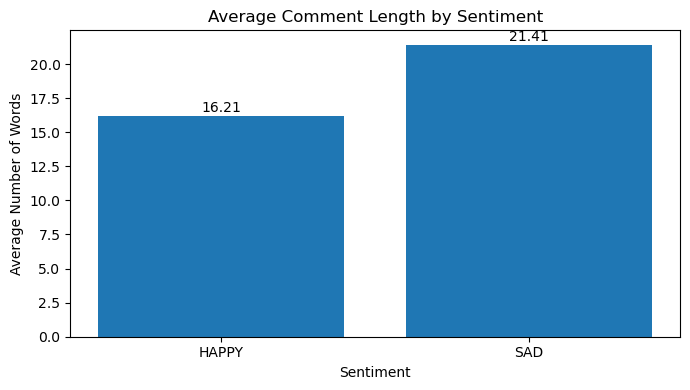

<Figure size 640x480 with 0 Axes>

In [129]:
average_length = (
    analysis_df.groupby("label")["word_count"]
    .mean()
    .reindex(["HAPPY", "SAD"])
)

plt.figure(figsize=(7, 4))

bars = plt.bar(
    average_length.index,
    average_length.values
)

plt.title("Average Comment Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")

for bar, value in zip(bars, average_length.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.3,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()
plt.savefig(
    PLOT_DIR / "average_comment_length.png",
    dpi=300,
    bbox_inches="tight"
)

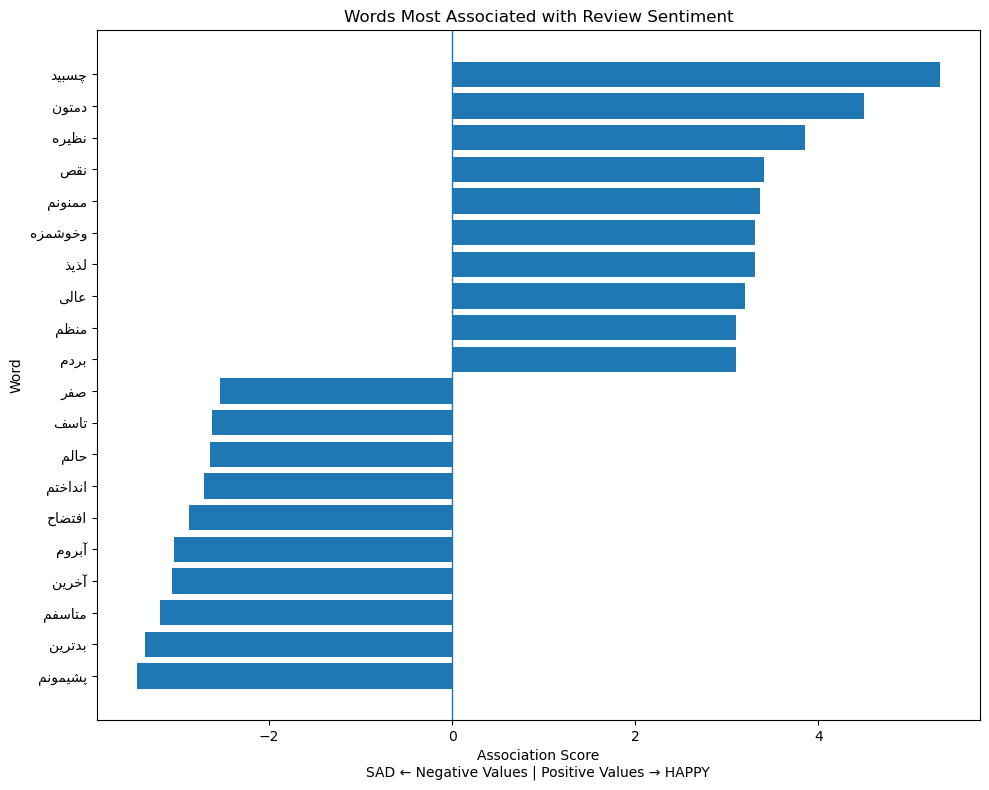

<Figure size 640x480 with 0 Axes>

In [131]:
final_word_plot = pd.concat([
    happy_associated.head(10),
    sad_associated.head(10)
]).sort_values("score")

plt.figure(figsize=(10, 8))

plt.barh(
    [
        persian_display(word)
        for word in final_word_plot["word"]
    ],
    final_word_plot["score"]
)

plt.axvline(0, linewidth=1)

plt.title("Words Most Associated with Review Sentiment")
plt.xlabel(
    "Association Score\n"
    "SAD ← Negative Values | Positive Values → HAPPY"
)
plt.ylabel("Word")

plt.tight_layout()
plt.show()
plt.savefig(
    PLOT_DIR / "final_word_associations.png",
    dpi=300,
    bbox_inches="tight"
)

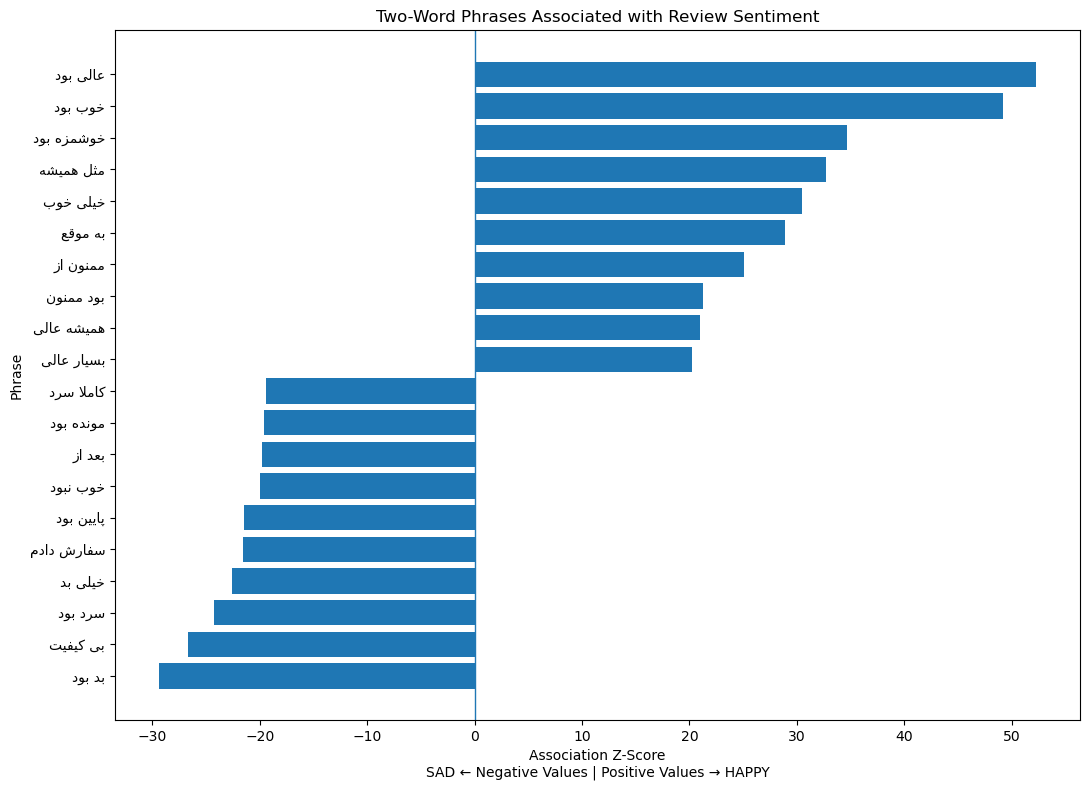

<Figure size 640x480 with 0 Axes>

In [132]:
final_phrase_plot = pd.concat([
    happy_phrases.head(10),
    sad_phrases.head(10)
]).sort_values("z_score")

plt.figure(figsize=(11, 8))

plt.barh(
    [
        persian_display(phrase)
        for phrase in final_phrase_plot["bigram"]
    ],
    final_phrase_plot["z_score"]
)

plt.axvline(0, linewidth=1)

plt.title("Two-Word Phrases Associated with Review Sentiment")
plt.xlabel(
    "Association Z-Score\n"
    "SAD ← Negative Values | Positive Values → HAPPY"
)
plt.ylabel("Phrase")

plt.tight_layout()
plt.show()
plt.savefig(
    PLOT_DIR / "final_phrase_associations.png",
    dpi=300,
    bbox_inches="tight"
)

<h2 style="color:#00BFC4;">Interpretation of the Main Results</h2>

<p>
The analysis showed clear differences between positive and negative
SnappFood comments. Positive reviews were strongly associated with words
expressing satisfaction, appreciation, taste, freshness, and service quality.
Negative reviews were associated with dissatisfaction, poor quality,
cold food, insufficient quantity, and regret.
</p>

<p>
Negative comments were also longer than positive comments. SAD reviews
contained an average of 21.41 words, compared with 16.21 words in HAPPY
reviews. This suggests that dissatisfied customers generally provide more
detail when describing problems.
</p>

<p>
Phrase analysis was especially useful because the meaning of an individual
word may change according to its context. For example, the word “نقص” appears
mainly in positive phrases such as “بی نقص” and “بدون نقص”. Similarly,
negation changes the meaning of positive words in phrases such as
“خوب نبود” and “راضی نبودم”.
</p>

<p>
Some phrases identified by the program describe topics or customer behaviour
rather than direct emotions. For example, “سیب زمینی” is common in both
sentiment groups. Therefore, statistically associated phrases should be
interpreted in context rather than automatically treated as positive or
negative vocabulary.
</p>